<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="380" alt="Skills Network Logo">
    </a>
</p>


# **Data Visualization Lab**


Estimated time needed: **45 to 60** minutes


In this assignment you will be focusing on the visualization of data.

The data set will be presented to you in the form of a RDBMS.

You will have to use SQL queries to extract the data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


<hr>


## Demo: How to work with database


Download database file.


In [1]:
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m4_survey_data.sqlite

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 34.9M  100 34.9M    0     0  8104k      0  0:00:04  0:00:04 --:--:-- 8105k


Connect to the database.


In [2]:
import sqlite3
conn = sqlite3.connect("m4_survey_data.sqlite") # open a database connection

Import pandas module.


In [3]:
import pandas as pd

## Demo: How to run an sql query


In [4]:
# print how many rows are there in the table named 'master'
QUERY = """
SELECT COUNT(*)
FROM master
"""

# the read_sql_query runs the sql query and returns the data as a dataframe
df = pd.read_sql_query(QUERY,conn)
df.head()

,COUNT(*)
0,11398


## Demo: How to list all tables


In [5]:
# print all the tables names in the database
QUERY = """
SELECT name as Table_Name FROM
sqlite_master WHERE
type = 'table'
"""
# the read_sql_query runs the sql query and returns the data as a dataframe
pd.read_sql_query(QUERY,conn)


,Table_Name
0,EduOther
1,DevType
2,LastInt
3,JobFactors
4,WorkPlan
5,WorkChallenge
6,LanguageWorkedWith
7,LanguageDesireNextYear
8,DatabaseWorkedWith
9,DatabaseDesireNextYear


## Demo: How to run a group by query


In [6]:
QUERY = """
SELECT Age,COUNT(*) as count
FROM master
group by age
order by age
"""
pd.read_sql_query(QUERY,conn)

,Age,count
0,NaN,287
1,16.0,3
2,17.0,6
3,18.0,29
4,19.0,78
5,20.0,109
6,21.0,203
7,22.0,406
8,23.0,581
9,24.0,679


## Demo: How to describe a table


In [7]:
table_name = 'master'  # the table you wish to describe

QUERY = """
SELECT sql FROM sqlite_master
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY,conn)
print(df.iat[0,0])

CREATE TABLE "master" (
"index" INTEGER,
  "Respondent" INTEGER,
  "MainBranch" TEXT,
  "Hobbyist" TEXT,
  "OpenSourcer" TEXT,
  "OpenSource" TEXT,
  "Employment" TEXT,
  "Country" TEXT,
  "Student" TEXT,
  "EdLevel" TEXT,
  "UndergradMajor" TEXT,
  "OrgSize" TEXT,
  "YearsCode" TEXT,
  "Age1stCode" TEXT,
  "YearsCodePro" TEXT,
  "CareerSat" TEXT,
  "JobSat" TEXT,
  "MgrIdiot" TEXT,
  "MgrMoney" TEXT,
  "MgrWant" TEXT,
  "JobSeek" TEXT,
  "LastHireDate" TEXT,
  "FizzBuzz" TEXT,
  "ResumeUpdate" TEXT,
  "CurrencySymbol" TEXT,
  "CurrencyDesc" TEXT,
  "CompTotal" REAL,
  "CompFreq" TEXT,
  "ConvertedComp" REAL,
  "WorkWeekHrs" REAL,
  "WorkRemote" TEXT,
  "WorkLoc" TEXT,
  "ImpSyn" TEXT,
  "CodeRev" TEXT,
  "CodeRevHrs" REAL,
  "UnitTests" TEXT,
  "PurchaseHow" TEXT,
  "PurchaseWhat" TEXT,
  "OpSys" TEXT,
  "BlockchainOrg" TEXT,
  "BlockchainIs" TEXT,
  "BetterLife" TEXT,
  "ITperson" TEXT,
  "OffOn" TEXT,
  "SocialMedia" TEXT,
  "Extraversion" TEXT,
  "ScreenName" TEXT,
  "SOVisit1st" T

# Hands-on Lab


## Visualizing distribution of data


### Histograms


Plot a histogram of `ConvertedComp.`


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: ConvertedComp, dtype: float64


(array([9659.,  238.,  115.,  125.,   99.,  131.,   34.,   15.,   15.,
         151.]),
 array([      0.,  200000.,  400000.,  600000.,  800000., 1000000.,
        1200000., 1400000., 1600000., 1800000., 2000000.]),
 <BarContainer object of 10 artists>)

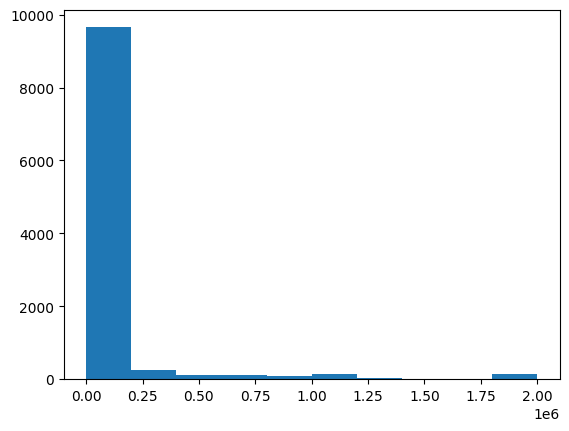

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

QUERY = """
SELECT *
FROM master
ORDER BY ConvertedComp ASC
"""
df = pd.read_sql_query(QUERY,conn)
print(df['ConvertedComp'].head())

plt.hist(df['ConvertedComp'])

### Box Plots


Plot a box plot of `Age.`


<Axes: >

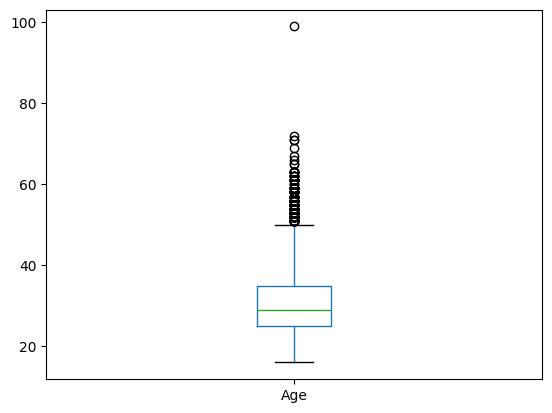

In [16]:
df.boxplot(column =['Age'],grid=False) 

## Visualizing relationships in data


### Scatter Plots


Create a scatter plot of `Age` and `WorkWeekHrs.`


<Axes: xlabel='Age', ylabel='WorkWeekHrs'>

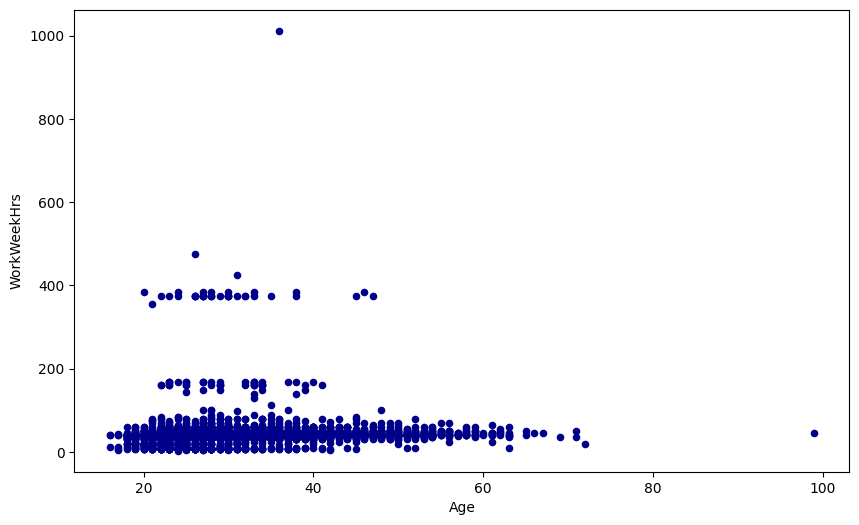

In [17]:
df.plot(kind='scatter', x='Age', y='WorkWeekHrs', figsize=(10, 6), color='darkblue')


### Bubble Plots


Create a bubble plot of `WorkWeekHrs` and `CodeRevHrs`, use `Age` column as bubble size.


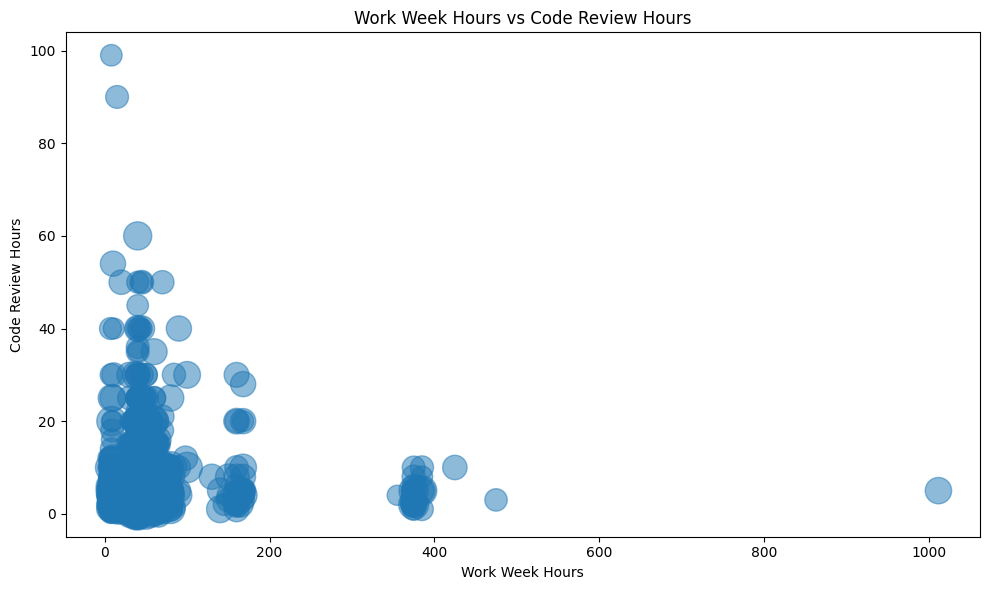

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["WorkWeekHrs"],
    df["CodeRevHrs"],
    s=df["Age"] * 10,   # bubble size
    alpha=0.5
)

plt.title("Work Week Hours vs Code Review Hours")
plt.xlabel("Work Week Hours")
plt.ylabel("Code Review Hours")

plt.tight_layout()
plt.show()

## Visualizing composition of data


### Pie Charts


Create a pie chart of the top 5 databases that respondents wish to learn next year. Label the pie chart with database names. Display percentages of each database on the pie chart.


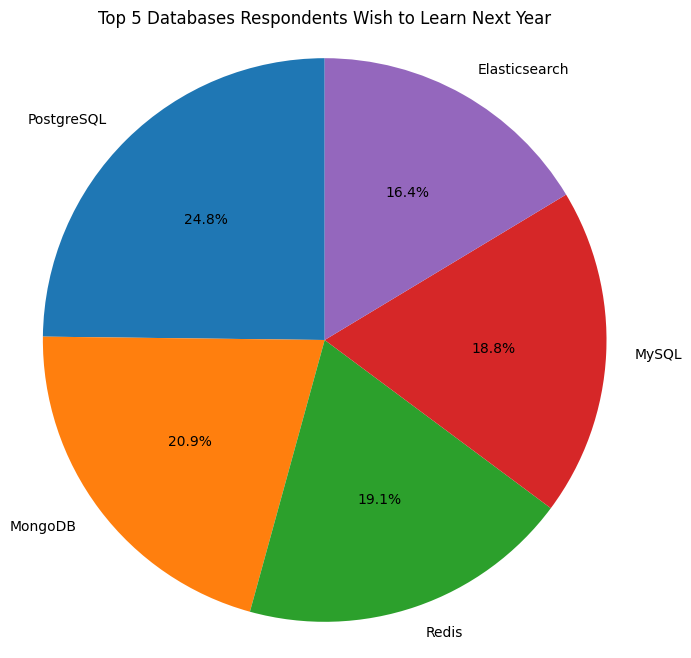

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Read SQL query results into a DataFrame
query = """
SELECT
    DatabaseDesireNextYear,
    COUNT(*) AS Respondents
FROM DatabaseDesireNextYear
GROUP BY DatabaseDesireNextYear
ORDER BY Respondents DESC
LIMIT 5
"""

df = pd.read_sql(query, conn)   # conn is your database connection

plt.figure(figsize=(8,8))
plt.pie(
    df["Respondents"],
    labels=df["DatabaseDesireNextYear"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 5 Databases Respondents Wish to Learn Next Year")
plt.axis("equal")
plt.show()

### Stacked Charts


Create a stacked chart of median `WorkWeekHrs` and `CodeRevHrs` for the age group 30 to 35.


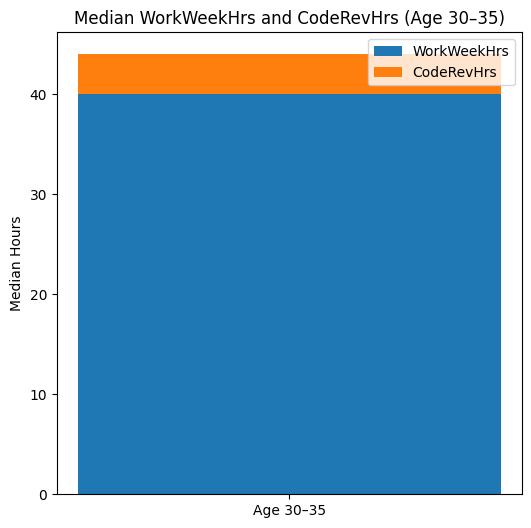

In [24]:
# Read data from the database into a DataFrame
query = """
SELECT
    Age,
    WorkWeekHrs,
    CodeRevHrs
FROM master
WHERE Age BETWEEN 30 AND 35
"""

df = pd.read_sql(query, conn)

# Find the median values for WorkWeekHrs and CodeRevHrs
median_work = df["WorkWeekHrs"].median()
median_rev= df["CodeRevHrs"].median()

#Create a stacked bar chart
plt.figure(figsize=(6,6))

plt.bar(
    "Age 30–35",
    median_work,
    label="WorkWeekHrs"
)

plt.bar(
    "Age 30–35",
    median_rev,
    bottom=median_work,
    label="CodeRevHrs"
)

plt.ylabel("Median Hours")
plt.title("Median WorkWeekHrs and CodeRevHrs (Age 30–35)")
plt.legend()

plt.show()

## Visualizing comparison of data


### Line Chart


Plot the median `ConvertedComp` for all ages from 45 to 60.


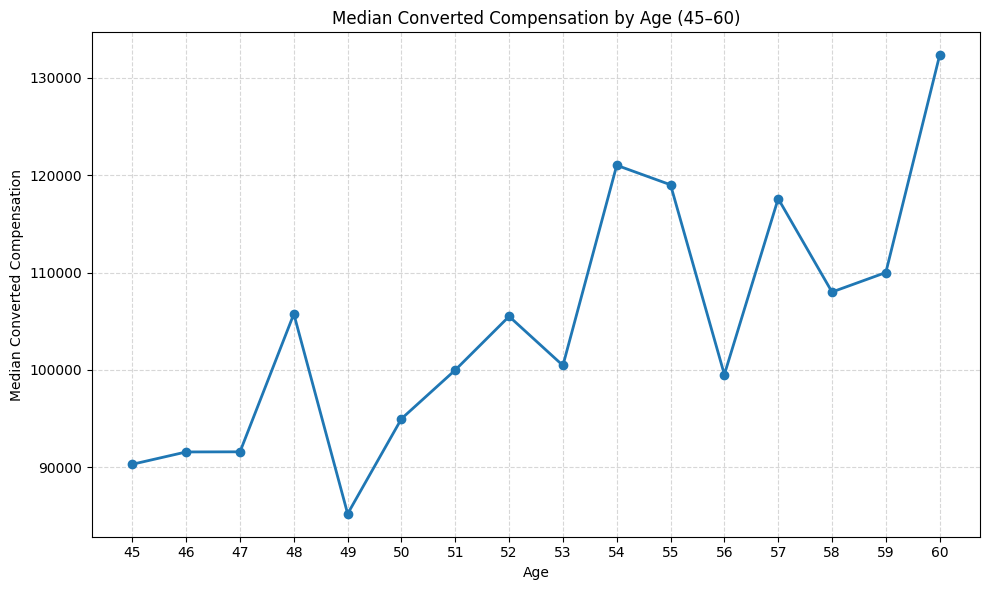

In [25]:
query = """
SELECT
    Age,
    ConvertedComp
FROM master
WHERE Age BETWEEN 45 AND 60
"""

df = pd.read_sql(query, conn)

median_salary = (
    df.groupby("Age")["ConvertedComp"]
      .median()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    median_salary["Age"],
    median_salary["ConvertedComp"],
    marker="o",
    linewidth=2
)

plt.title("Median Converted Compensation by Age (45–60)")
plt.xlabel("Age")
plt.ylabel("Median Converted Compensation")
plt.xticks(range(45, 61))

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

### Bar Chart


Create a horizontal bar chart using column `MainBranch.`


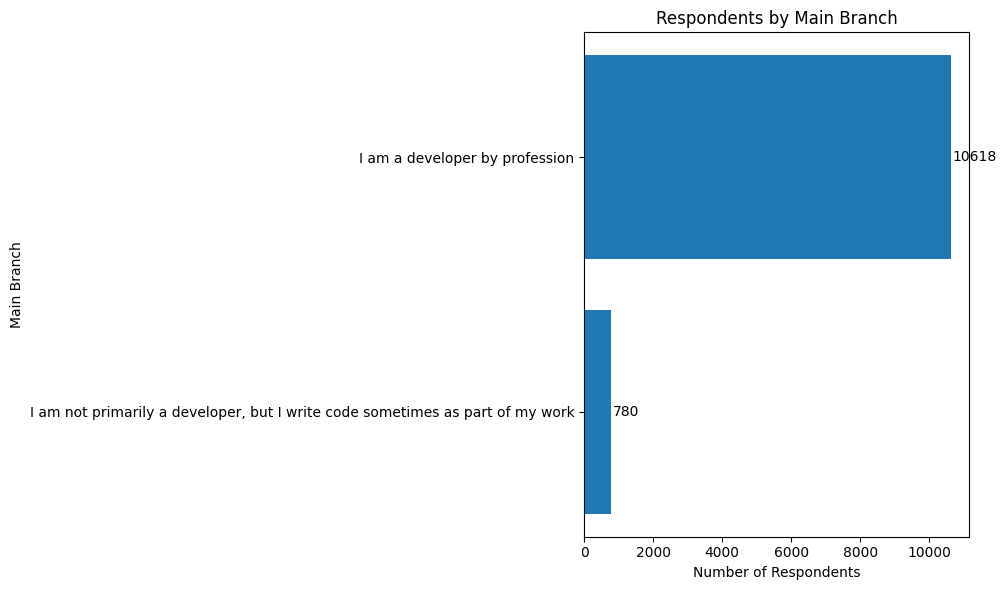

In [26]:
# Query the data
query = """
SELECT MainBranch
FROM master
"""

df = pd.read_sql(query, conn)

# Count respondents by MainBranch
mainbranch_counts = (
    df["MainBranch"]
    .value_counts()
    .sort_values(ascending=True)   # Smallest at top, largest at bottom
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(
    mainbranch_counts.index,
    mainbranch_counts.values
)

# Add data labels
for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va="center"
    )

plt.title("Respondents by Main Branch")
plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")

plt.tight_layout()
plt.show()


Close the database connection.


In [27]:
conn.close()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


 Copyright © 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license?cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ).


<!--## Change Log


<!--| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |--!>
